Import Model Configuration
==========================

In [1]:
import yaml

model_cfg = "maskrcnn_resnet101_fpn.yaml"

with open("./configs/" + model_cfg , "r") as f:
    cfg = yaml.safe_load(f)

cfg['experiment_name']

'maskrcnn_resnet101_fpn'

Dataset Class
=============

In [2]:
import os
import torch
from torch.utils.data import Dataset
from torchvision.io import read_image
from torchvision import tv_tensors
from torchvision.transforms.v2 import functional as F
from pycocotools.coco import COCO
from pycocotools import mask as coco_mask
import numpy as np


class COCOSegmentationDataset(Dataset):
    def __init__(self, root_dir, transforms=None):
        self.root_dir = root_dir
        self.transforms = transforms

        # path to the JSON annotation file
        self.ann_path = os.path.join(root_dir, "_annotations.coco.json")
        self.coco = COCO(self.ann_path)
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        coco = self.coco
        img_id = self.ids[index]
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.root_dir, img_info['file_name'])

        img = read_image(img_path)  # shape: [C, H, W]
        img = tv_tensors.Image(img)
        h, w = img.shape[-2:]

        ann_ids = coco.getAnnIds(imgIds=img_id)
        anns = coco.loadAnns(ann_ids)

        masks = []
        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for ann in anns:
            if 'segmentation' not in ann:
                continue

            rles = coco_mask.frPyObjects(ann['segmentation'], h, w)
            mask = coco_mask.decode(rles)
            if mask.ndim == 3:
                mask = mask.any(axis=2)
            mask = torch.as_tensor(mask, dtype=torch.uint8)
            masks.append(mask)

            x, y, bw, bh = ann['bbox']
            boxes.append(torch.tensor([x, y, x + bw, y + bh], dtype=torch.float32))
            labels.append(ann.get('category_id', 1))
            areas.append(ann['area'])
            iscrowd.append(ann.get('iscrowd', 0))

        if masks:
            masks = torch.stack(masks)
            boxes = torch.stack(boxes)
            labels = torch.tensor(labels, dtype=torch.int64)
            areas = torch.tensor(areas, dtype=torch.float32)
            iscrowd = torch.tensor(iscrowd, dtype=torch.int64)
        else:
            masks = torch.zeros((0, h, w), dtype=torch.uint8)
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            areas = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=(h, w)),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": img_id,
            "area": areas,
            "iscrowd": iscrowd
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)

            # ⚠️ Filter out zero-area boxes *after transforms*
            boxes = target["boxes"]
            keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])

            # Apply keep mask to all fields
            target["boxes"] = tv_tensors.BoundingBoxes(boxes[keep], format="XYXY", canvas_size=img.shape[-2:])
            target["labels"] = target["labels"][keep]
            if "masks" in target:
                target["masks"] = target["masks"][keep]
            if "area" in target:
                target["area"] = target["area"][keep]
            if "iscrowd" in target:
                target["iscrowd"] = target["iscrowd"][keep]

        return img, target

    def __len__(self):
        return len(self.ids)


Augmentiations
=============

In [ ]:
from torchvision.transforms import v2 as T
import torch

def get_transform(train: bool):
    if train:
        transforms = [
            T.RandomPhotometricDistort(),  # Color jitter
            T.Resize((512, 512)),          # Fixed resize for stability
            T.RandomHorizontalFlip(p=0.5),
            T.RandomRotation(degrees=10, fill=0, expand=False),  # Limit rotation area
            # T.RandomZoomOut(fill=0, p=0.3),  # Optional — leave off for now
            # T.RandomCrop((512, 512), pad_if_needed=False, fill=0),  # Only if images are bigger
        ]
    else:
        transforms = [
            T.Resize((512, 512)),                                   # Consistent resize for val/test
        ]

    transforms += [
        T.ToDtype(torch.float32, scale=True),                       # Convert image to float32 in [0, 1]
        T.ToPureTensor(),                                           # Convert to torch.Tensor (Image, Mask, BBoxes)
    ]

    return T.Compose(transforms)

Log Hyperparams to TensorBoard
===============================

In [4]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import shutil, os

timestamp = datetime.now().strftime("%Y%m%d_%H%M")

log_dir = f"runs/{cfg['experiment_name']}_{timestamp}"

if os.path.exists(log_dir):
    shutil.rmtree(log_dir)

# Save cfg as hyperparameters (flatten dictionary)
def flatten_dict(d, parent_key="", sep="/"):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

writer = SummaryWriter(log_dir=f"runs/{cfg['experiment_name']}_{timestamp}")

# Option 1: Save flattened cfg to TensorBoard as hparams
flattened_cfg = flatten_dict(cfg)

# Option 2: Also log as text (for easier reading)
cfg_text = yaml.dump(cfg, sort_keys=False)
writer.add_text("config", f"```yaml\n{cfg_text}\n```")


Initialization
=============

In [5]:
import utils  # Your helper functions (make sure it includes `collate_fn` from PyTorch references)
import torch
from torchvision.transforms import v2 as T
from engine import train_one_epoch, evaluate

from tqdm import tqdm
import sys
import time

from models import MODEL_REGISTRY



device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# COCO-style dataset using your structure
dataset = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/train",
    transforms=get_transform(train=True)
)

dataset_valid = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/valid",
    transforms=get_transform(train=False)
)

dataset_test = COCOSegmentationDataset(
    root_dir="../../../BubANN_GAN.v1i.coco-segmentation/test",
    transforms=get_transform(train=False)
)


print("Train size:", len(dataset))
print("Validation size:", len(dataset_valid))
print("Test size:", len(dataset_test))

# Dynamically assign number of workers
n_workers = 4 if torch.cuda.is_available() else 0

# Dataloaders
data_loader = torch.utils.data.DataLoader(
    dataset,
    batch_size=cfg["train"]["batch_size"],
    shuffle=True,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

data_loader_valid = torch.utils.data.DataLoader(
    dataset_valid,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test,
    batch_size=1,
    shuffle=False,
    num_workers=n_workers,
    collate_fn=utils.collate_fn
)

# Two classes: background + foreground
num_classes = cfg['num_classes']

# Load model
model = MODEL_REGISTRY[cfg["model"]](num_classes=cfg["num_classes"])
#model = get_model_instance_segmentation(num_classes)

model.to(device)

loading annotations into memory...
Done (t=0.21s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Train size: 1049
Validation size: 300
Test size: 150


/home/jotac431/miniconda3/envs/coco-env/lib/python3.10/site-packages/torchvision/models/_utils.py:135: UserWarning: Using 'backbone_name' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=1e-05)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=1e-05)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=1e-05)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=1e-05)
          (relu):

Train
=====

In [6]:
import csv

# Optimizer and LR scheduler from config
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(
    params,
    lr=cfg["train"]["lr"],
    momentum=cfg["train"]["momentum"],
    weight_decay=cfg["train"]["weight_decay"],
)
lr_scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=cfg["train"]["lr_step_size"],
    gamma=cfg["train"]["gamma"],
)


num_epochs = cfg['train']['epochs']
print("Start training...")

#scaler = torch.cuda.amp.GradScaler()  # Enable AMP if you want (optional)
scaler = torch.amp.GradScaler()  # Updated for modern AMP


cfg["output_dir"] = f"outputs/{cfg['experiment_name']}_{timestamp}"
os.makedirs(cfg["output_dir"], exist_ok=True)

best_val = -float("inf")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    sys.stdout.flush()

    start_time = time.time()

    # tqdm-wrapped version of the training loop
    model.train()
    metric_logger = utils.MetricLogger(delimiter="  ")
    metric_logger.add_meter("lr", utils.SmoothedValue(window_size=1, fmt="{value:.6f}"))

    header = f"Epoch: [{epoch}]"

    # Optional warmup scheduler for the first epoch
    warmup_scheduler = None
    if epoch == 0:
        warmup_factor = 1.0 / 1000
        warmup_iters = min(1000, len(data_loader) - 1)
        warmup_scheduler = torch.optim.lr_scheduler.LinearLR(
            optimizer, start_factor=warmup_factor, total_iters=warmup_iters
        )

    for batch_idx, (images, targets) in enumerate(tqdm(data_loader, desc=header)):
        images = list(img.to(device) for img in images)
        #targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        targets = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in targets]

        # Mixed precision (optional)
        #with torch.cuda.amp.autocast(enabled=False):  # Set to True to enable AMP
        with torch.amp.autocast(device_type='cuda', enabled=False):  # Set to True to enable AMP
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        # Check for NaN or inf loss
        if not torch.isfinite(losses):
            print(f"[!] Loss is {losses.item()}, stopping training")
            print(loss_dict)
            sys.exit(1)

        optimizer.zero_grad()
        # AMP (uncomment if you enable autocast)
        # scaler.scale(losses).backward()
        # scaler.step(optimizer)
        # scaler.update()

        losses.backward()
        optimizer.step()

        if warmup_scheduler is not None:
            warmup_scheduler.step()

        metric_logger.update(loss=losses.item(), **loss_dict)
        metric_logger.update(lr=optimizer.param_groups[0]["lr"])

        # Log to TensorBoard
        global_step = epoch * len(data_loader) + batch_idx
        writer.add_scalar("Train/Loss", losses.item(), global_step)
        writer.add_scalar("Train/LR", optimizer.param_groups[0]["lr"], global_step)

    lr_scheduler.step()
    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1} completed in {epoch_time:.2f} seconds.")
    


    # Validation
    print("Evaluating on validation set:")
    coco_evaluator = evaluate(model, data_loader_valid, device=device)

    # Extract segmentation (IoU type: 'segm') metrics
    segm_eval = coco_evaluator.coco_eval["segm"]
    segm_stats = segm_eval.stats  # List of 12 standard COCO segmentation metrics

    # Path to the CSV file
    csv_path = os.path.join(cfg["output_dir"], "segm_metrics.csv")

    # Write header once if file doesn't exist
    if epoch == 0 and not os.path.exists(csv_path):
        with open(csv_path, mode='w', newline='') as f:
            csv_writer = csv.writer(f)
            csv_writer.writerow([
                "epoch",
                "AP@[IoU=0.50:0.95]",
                "AP@0.50",
                "AP@0.75",
                "AP_small",
                "AP_medium",
                "AP_large",
                "AR@max=1",
                "AR@max=10",
                "AR@max=100",
                "AR_small",
                "AR_medium",
                "AR_large"
            ])

    # Append metrics every epoch
    with open(csv_path, mode='a', newline='') as f:
        csv_writer = csv.writer(f)
        csv_writer.writerow([epoch] + list(segm_stats))
        

    # Log COCO-style mAP scores for segmentation
    writer.add_scalar("Val/segm_mAP", segm_stats[0], epoch)
    writer.add_scalar("Val/segm_mAP_50", segm_stats[1], epoch)
    writer.add_scalar("Val/segm_mAP_75", segm_stats[2], epoch)
    writer.add_scalar("Val/segm_mAP_small", segm_stats[3], epoch)
    writer.add_scalar("Val/segm_mAP_medium", segm_stats[4], epoch)
    writer.add_scalar("Val/segm_mAP_large", segm_stats[5], epoch)
    # Additional COCO segmentation recall metrics
    writer.add_scalar("Val/segm_AR_max1", segm_stats[6], epoch)
    writer.add_scalar("Val/segm_AR_max10", segm_stats[7], epoch)
    writer.add_scalar("Val/segm_AR_max100", segm_stats[8], epoch)
    writer.add_scalar("Val/segm_AR_small", segm_stats[9], epoch)
    writer.add_scalar("Val/segm_AR_medium", segm_stats[10], epoch)
    writer.add_scalar("Val/segm_AR_large", segm_stats[11], epoch)


    # Use segm mAP as your validation score
    current_val = segm_stats[0]  # mAP @ IoU=.50:.95 (primary COCO metric)

    # Create output directory if it doesn't exist
    os.makedirs(cfg["output_dir"], exist_ok=True)

    if current_val > best_val:  # For mAP, higher is better
        best_val = current_val

        # Save model weights
        torch.save(model.state_dict(), os.path.join(cfg["output_dir"], "model_best.pth"))

        # Optionally: save full checkpoint (model + optimizer + scheduler + epoch)
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'lr_scheduler_state_dict': lr_scheduler.state_dict(),
        }, os.path.join(cfg["output_dir"], "checkpoint_best.pth"))


print("\nThat's it!")

Start training...

Epoch 1/10


Epoch: [0]: 100%|██████████| 525/525 [06:29<00:00,  1.35it/s]


Epoch 1 completed in 389.74 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:04  model_time: 0.4695 (0.4695)  evaluator_time: 0.0171 (0.0171)  time: 0.6162  data: 0.1245  max mem: 3026
Test:  [100/300]  eta: 0:00:41  model_time: 0.1637 (0.1783)  evaluator_time: 0.0126 (0.0217)  time: 0.2051  data: 0.0044  max mem: 3026
Test:  [200/300]  eta: 0:00:20  model_time: 0.1563 (0.1783)  evaluator_time: 0.0107 (0.0234)  time: 0.2082  data: 0.0045  max mem: 3026
Test:  [299/300]  eta: 0:00:00  model_time: 0.1586 (0.1756)  evaluator_time: 0.0113 (0.0223)  time: 0.1831  data: 0.0046  max mem: 3026
Test: Total time: 0:01:01 (0.2045 s / it)
Averaged stats: model_time: 0.1586 (0.1756)  evaluator_time: 0.0113 (0.0223)
Accumulating evaluation results...
DONE (t=0.09s).
Accumulating evaluation results...
DONE (t=0.07s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.671
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [1]: 100%|██████████| 525/525 [06:41<00:00,  1.31it/s]


Epoch 2 completed in 401.60 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:01:44  model_time: 0.1992 (0.1992)  evaluator_time: 0.0164 (0.0164)  time: 0.3487  data: 0.1311  max mem: 3057
Test:  [100/300]  eta: 0:00:40  model_time: 0.1621 (0.1730)  evaluator_time: 0.0116 (0.0213)  time: 0.2064  data: 0.0049  max mem: 3057
Test:  [200/300]  eta: 0:00:21  model_time: 0.2071 (0.1802)  evaluator_time: 0.0132 (0.0245)  time: 0.2797  data: 0.0082  max mem: 3057
Test:  [299/300]  eta: 0:00:00  model_time: 0.1583 (0.1800)  evaluator_time: 0.0092 (0.0223)  time: 0.1786  data: 0.0043  max mem: 3057
Test: Total time: 0:01:02 (0.2095 s / it)
Averaged stats: model_time: 0.1583 (0.1800)  evaluator_time: 0.0092 (0.0223)
Accumulating evaluation results...
DONE (t=0.07s).
Accumulating evaluation results...
DONE (t=0.06s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.791
 Average Precision  (AP) @[ IoU=0.50  

...

Epoch 8 completed in 402.06 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:34  model_time: 0.5497 (0.5497)  evaluator_time: 0.0107 (0.0107)  time: 0.7136  data: 0.1495  max mem: 3057
Test:  [100/300]  eta: 0:00:38  model_time: 0.1579 (0.1691)  evaluator_time: 0.0100 (0.0172)  time: 0.1944  data: 0.0045  max mem: 3057
Test:  [200/300]  eta: 0:00:19  model_time: 0.1526 (0.1681)  evaluator_time: 0.0070 (0.0188)  time: 0.1921  data: 0.0044  max mem: 3057
Test:  [299/300]  eta: 0:00:00  model_time: 0.1463 (0.1648)  evaluator_time: 0.0061 (0.0175)  time: 0.1658  data: 0.0042  max mem: 3057
Test: Total time: 0:00:56 (0.1888 s / it)
Averaged stats: model_time: 0.1463 (0.1648)  evaluator_time: 0.0061 (0.0175)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.842
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [8]: 100%|██████████| 525/525 [06:42<00:00,  1.31it/s]


Epoch 9 completed in 402.11 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:02:36  model_time: 0.3640 (0.3640)  evaluator_time: 0.0116 (0.0116)  time: 0.5204  data: 0.1409  max mem: 3057
Test:  [100/300]  eta: 0:00:38  model_time: 0.1585 (0.1659)  evaluator_time: 0.0122 (0.0170)  time: 0.1898  data: 0.0043  max mem: 3057
Test:  [200/300]  eta: 0:00:19  model_time: 0.1546 (0.1668)  evaluator_time: 0.0068 (0.0190)  time: 0.1909  data: 0.0042  max mem: 3057
Test:  [299/300]  eta: 0:00:00  model_time: 0.1474 (0.1640)  evaluator_time: 0.0064 (0.0178)  time: 0.1686  data: 0.0043  max mem: 3057
Test: Total time: 0:00:56 (0.1884 s / it)
Averaged stats: model_time: 0.1474 (0.1640)  evaluator_time: 0.0064 (0.0178)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.05s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.838
 Average Precision  (AP) @[ IoU=0.50  

Epoch: [9]: 100%|██████████| 525/525 [06:42<00:00,  1.30it/s]


Epoch 10 completed in 402.57 seconds.
Evaluating on validation set:
creating index...
index created!
Test:  [  0/300]  eta: 0:03:25  model_time: 0.4931 (0.4931)  evaluator_time: 0.0123 (0.0123)  time: 0.6857  data: 0.1766  max mem: 3057
Test:  [100/300]  eta: 0:00:38  model_time: 0.1563 (0.1678)  evaluator_time: 0.0104 (0.0173)  time: 0.1897  data: 0.0043  max mem: 3057
Test:  [200/300]  eta: 0:00:19  model_time: 0.1522 (0.1656)  evaluator_time: 0.0059 (0.0182)  time: 0.1873  data: 0.0043  max mem: 3057
Test:  [299/300]  eta: 0:00:00  model_time: 0.1481 (0.1635)  evaluator_time: 0.0058 (0.0174)  time: 0.1682  data: 0.0043  max mem: 3057
Test: Total time: 0:00:56 (0.1875 s / it)
Averaged stats: model_time: 0.1481 (0.1635)  evaluator_time: 0.0058 (0.0174)
Accumulating evaluation results...
DONE (t=0.05s).
Accumulating evaluation results...
DONE (t=0.06s).
IoU metric: bbox
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.842
 Average Precision  (AP) @[ IoU=0.50 

In [7]:
# === Log hyperparameters and final validation metric ===
from torch.utils.tensorboard import SummaryWriter

flattened_cfg = flatten_dict(cfg)

writer.add_hparams(
    hparam_dict=flattened_cfg,
    metric_dict={"Val/best_mAP": best_val}
)

writer.close()

Test (Example)
=====

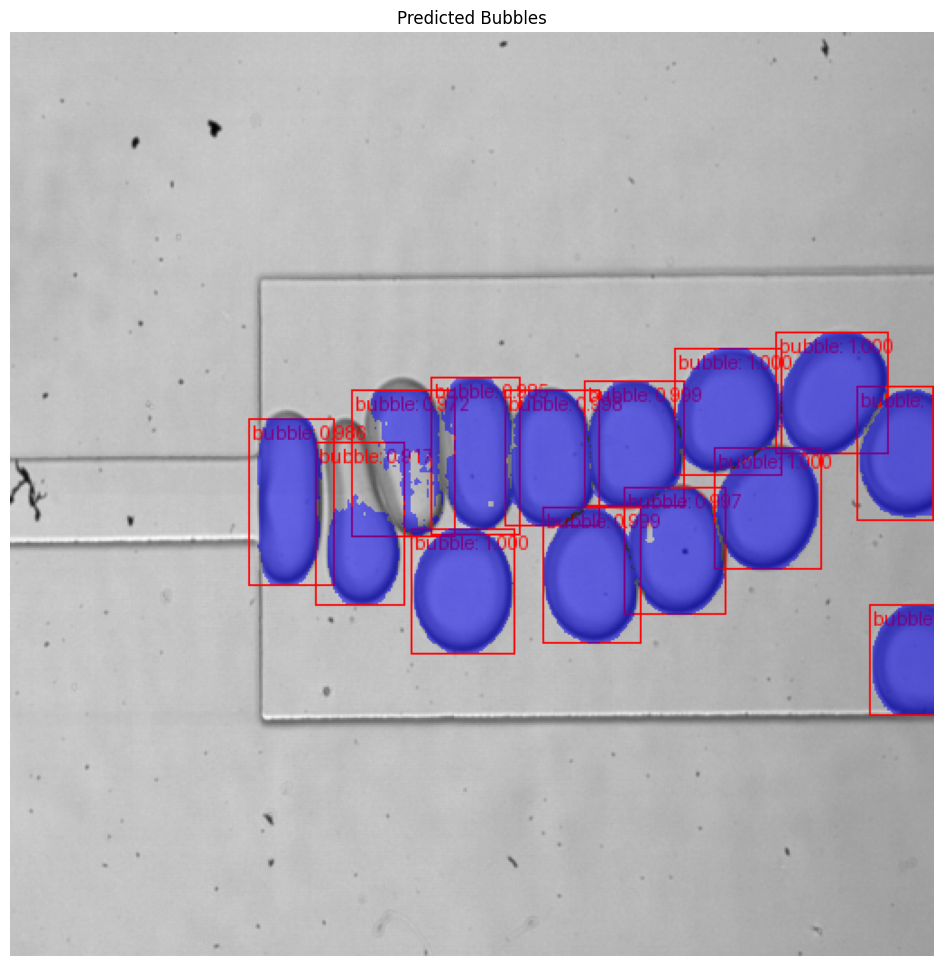

In [11]:
import matplotlib.pyplot as plt
from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torch

#image = read_image("../../../BubANN_GAN.v1i.coco-segmentation/test/BubGAN_0002_jpg.rf.a78f79c439aaf0c4cfcaac4ce751a071.jpg")
#image = read_image("../../../frames_ana\\02_07_20\\qc2_qd1_10x_formacao\\qc2_qd1_10x_formacao_00000.jpg")
#image = read_image("../../../frames_ana/02_07_20/qc2_qd1_10x_formacao2/qc2_qd1_10x_formacao2_00000.jpg")
image = read_image("../../../datasets/frames_ana/02_07_20/qc2_qd1_10x_formacao2/qc2_qd1_10x_formacao2_00000.jpg")
eval_transform = get_transform(train=False)

score_thresh = 0.9  # Confidence threshold
min_area = 500     # Minimum bubble size in pixels

model.eval()
with torch.no_grad():
    x = eval_transform(image)
    x = x[:3, ...].to(device)

    predictions = model([x])
    pred = predictions[0]

# Filter predictions by score
keep = pred["scores"] > score_thresh
scores = pred["scores"][keep]
boxes = pred["boxes"][keep]
masks = pred["masks"][keep]

# Filter masks by area (size)
areas = masks.sum(dim=[1, 2, 3])  # Sum over HxW for each mask
keep_area = areas > min_area

# Final filtered outputs
boxes = boxes[keep_area].cpu().long()
masks = (masks[keep_area].cpu() > 0.7).squeeze(1)
labels = [f"bubble: {score:.3f}" for score in scores[keep_area]]

# Prepare image for visualization (use x)
vis_img = (255.0 * (x.cpu() - x.cpu().min()) / (x.cpu().max() - x.cpu().min())).to(torch.uint8)
vis_img = vis_img[:3, ...]

#pred_labels = [f"bubble: {score:.3f}" for score in pred["scores"]]
#pred_boxes = pred["boxes"].cpu().long()
#masks = (pred["masks"].cpu() > 0.7).squeeze(1)

output_image = draw_bounding_boxes(vis_img, boxes, labels, colors="red")
output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

plt.figure(figsize=(12, 12))
plt.imshow(output_image.permute(1, 2, 0))
plt.axis("off")
plt.title("Predicted Bubbles")
plt.show()

Resume Training from Checkpoint (Example)
==========================================

In [ ]:
'''
checkpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
start_epoch = checkpoint['epoch']

or

checkpoint = torch.load("checkpoint_best.pth")
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
lr_scheduler.load_state_dict(checkpoint['lr_scheduler_state_dict'])
start_epoch = checkpoint['epoch']
'''

'\ncheckpoint = torch.load("outputs/maskrcnn_baseline/checkpoint_epoch_3.pth")\nmodel.load_state_dict(checkpoint[\'model_state_dict\'])\noptimizer.load_state_dict(checkpoint[\'optimizer_state_dict\'])\nlr_scheduler.load_state_dict(checkpoint[\'lr_scheduler_state_dict\'])\nstart_epoch = checkpoint[\'epoch\']\n'

Test Batch
=========

Image 0
Precision: 0.9771329746348962
Recall: 0.9829885946259423
F1: 0.9800520381613183
Intersection: 10170
Union: 10584
Dice: 0.9800520381140959
Drawing predictions...


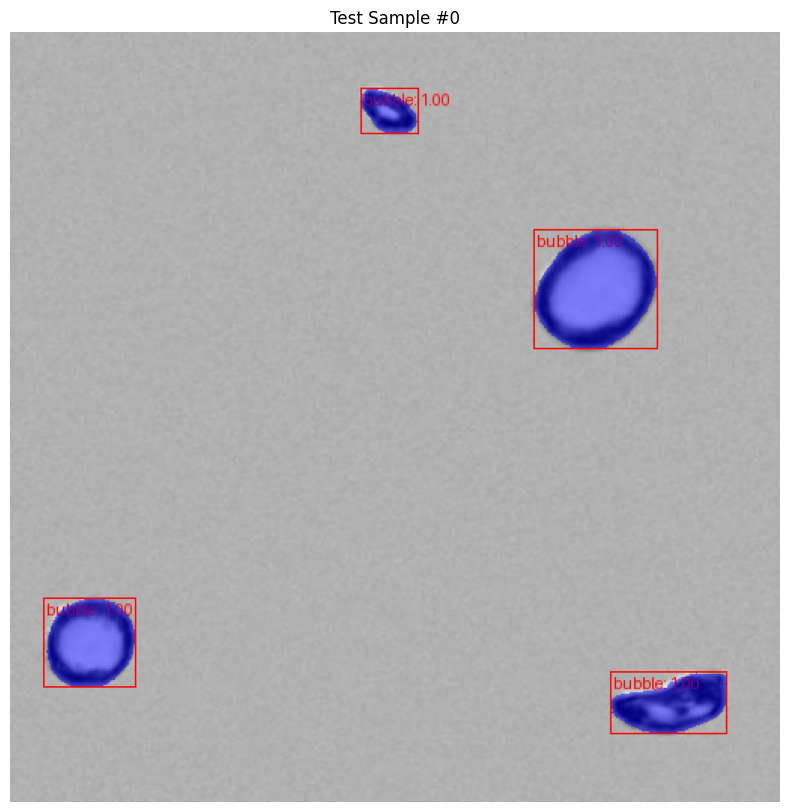

Image 1
Precision: 0.9944607677857521
Recall: 0.925829596412556
F1: 0.958918743178282
Intersection: 20646
Union: 22415
Dice: 0.9589187431560131
Drawing predictions...


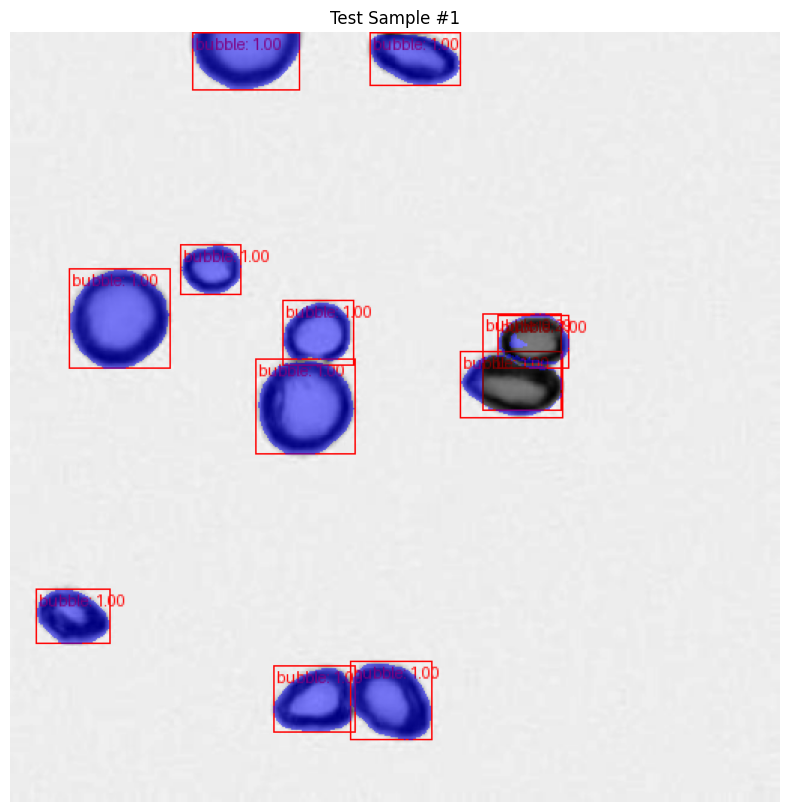

Image 2
Precision: 0.9993446651648576
Recall: 0.8917437228171485
F1: 0.9424830037082819
Intersection: 24399
Union: 27377
Dice: 0.9424830036900788
Drawing predictions...


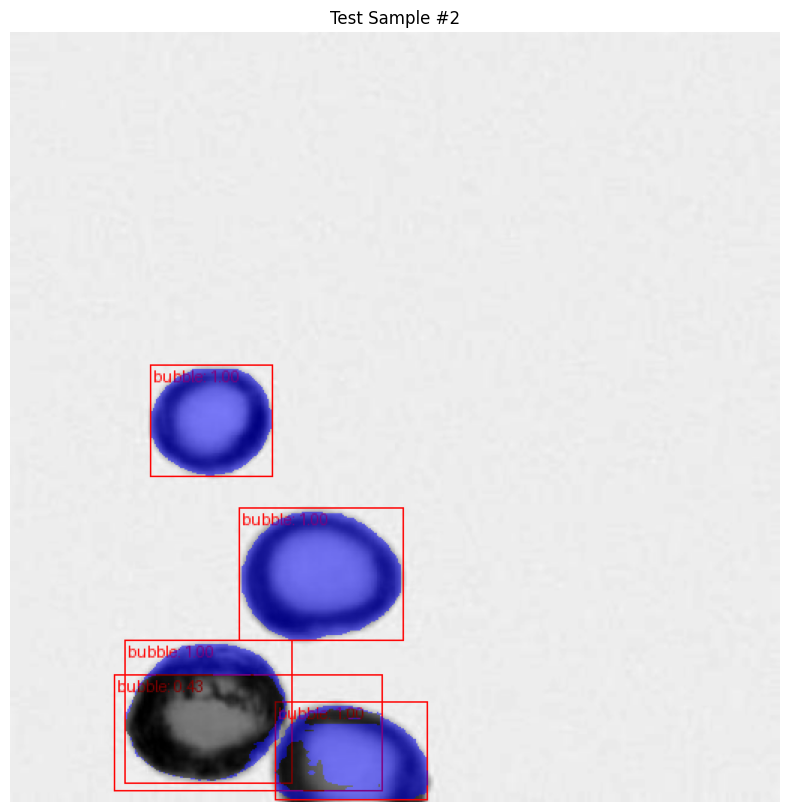

Image 3
Precision: 0.9310775782262544
Recall: 0.99254909700977
F1: 0.960831144017196
Intersection: 20115
Union: 21755
Dice: 0.9608311439942481
Drawing predictions...


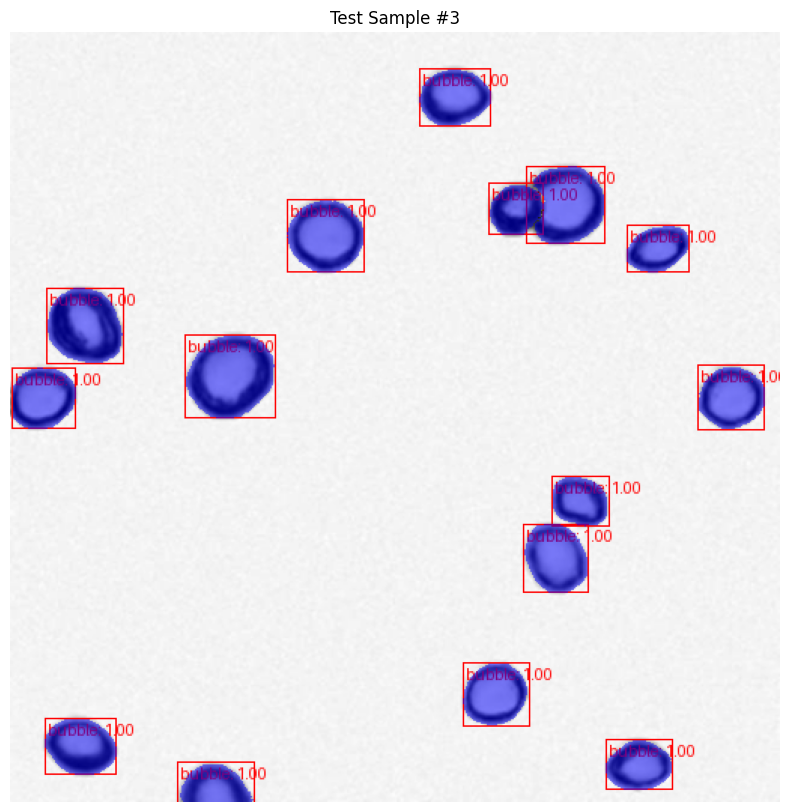

Image 4
Precision: 0.9644209956709957
Recall: 0.9773786673978613
F1: 0.9708565981206592
Intersection: 14258
Union: 15114
Dice: 0.9708565980876053
Drawing predictions...


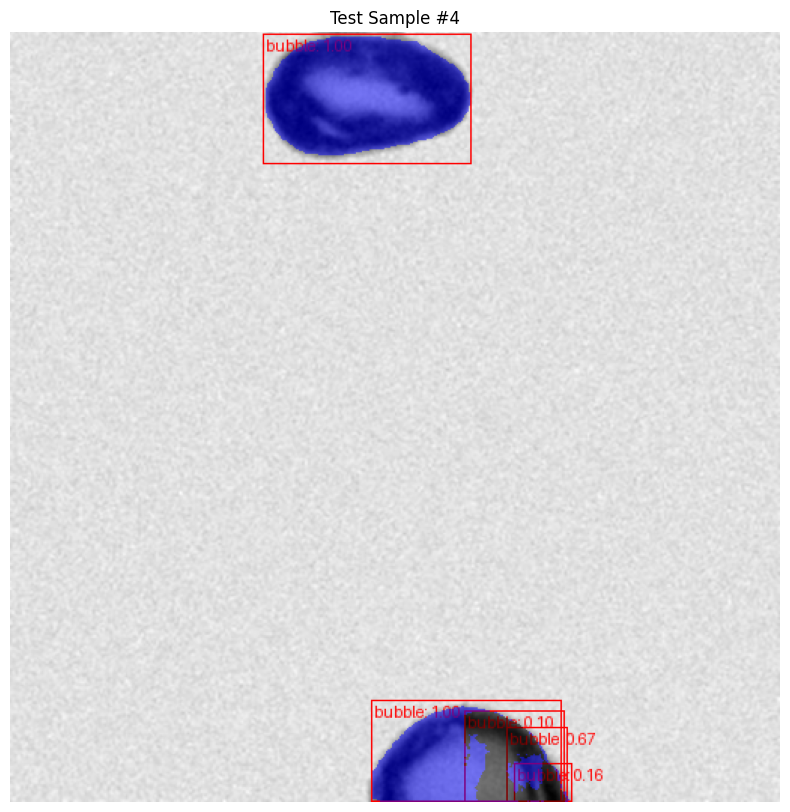

Image 5
Precision: 0.9762660872472004
Recall: 0.9877399171387503
F1: 0.9819694868238558
Intersection: 23364
Union: 24222
Dice: 0.98196948680322
Drawing predictions...


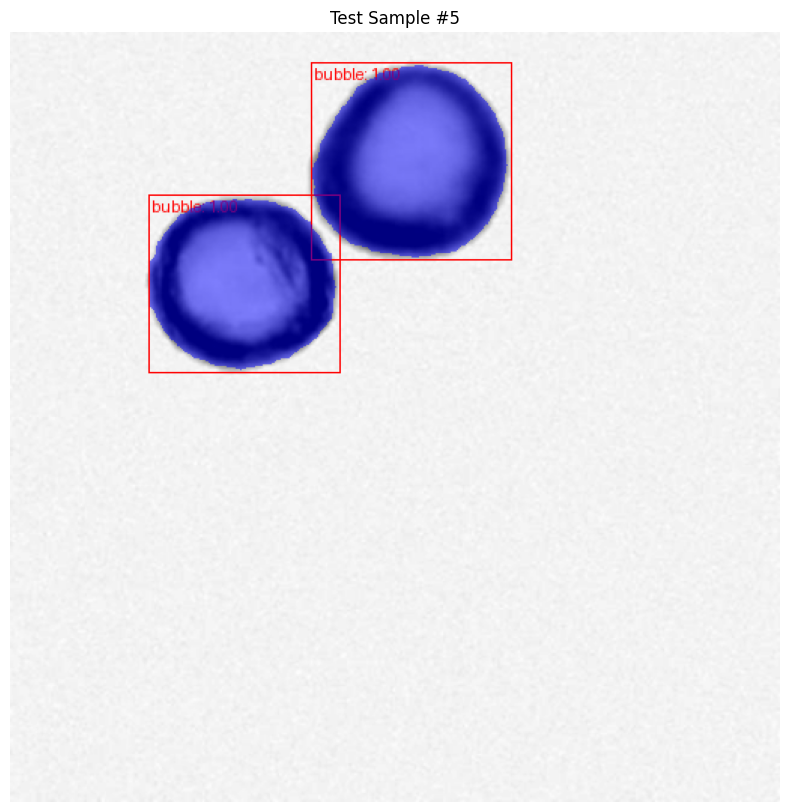

Image 6
Precision: 0.99918990364117
Recall: 0.880683953400977
F1: 0.9362016618728028
Intersection: 23435
Union: 26629
Dice: 0.9362016618541027
Drawing predictions...


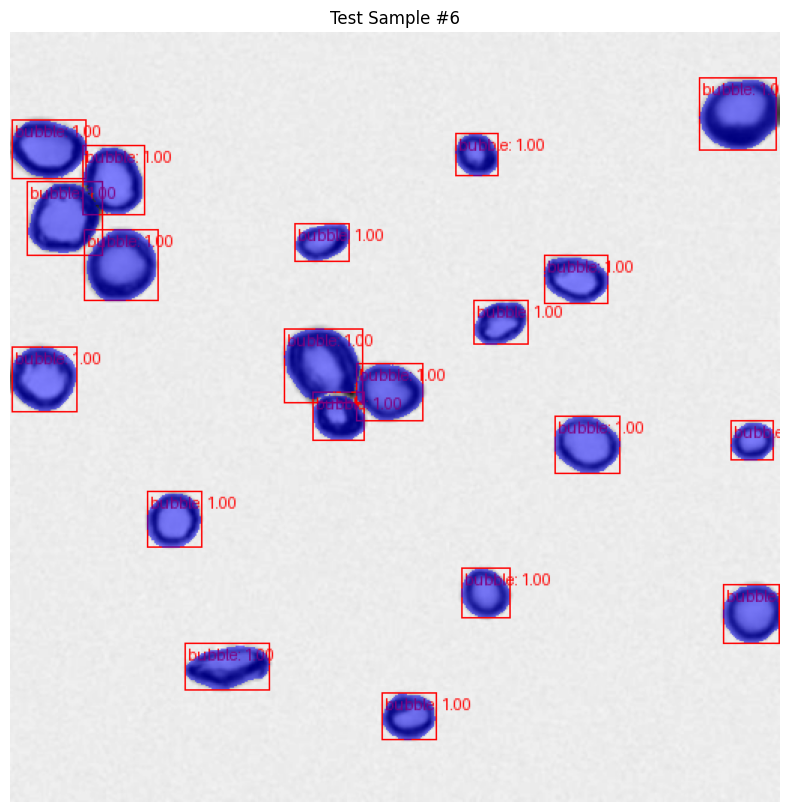

Image 7
Precision: 0.9974891457864727
Recall: 0.9108234619793657
F1: 0.9521883504356727
Intersection: 19069
Union: 20984
Dice: 0.9521883504118995
Drawing predictions...


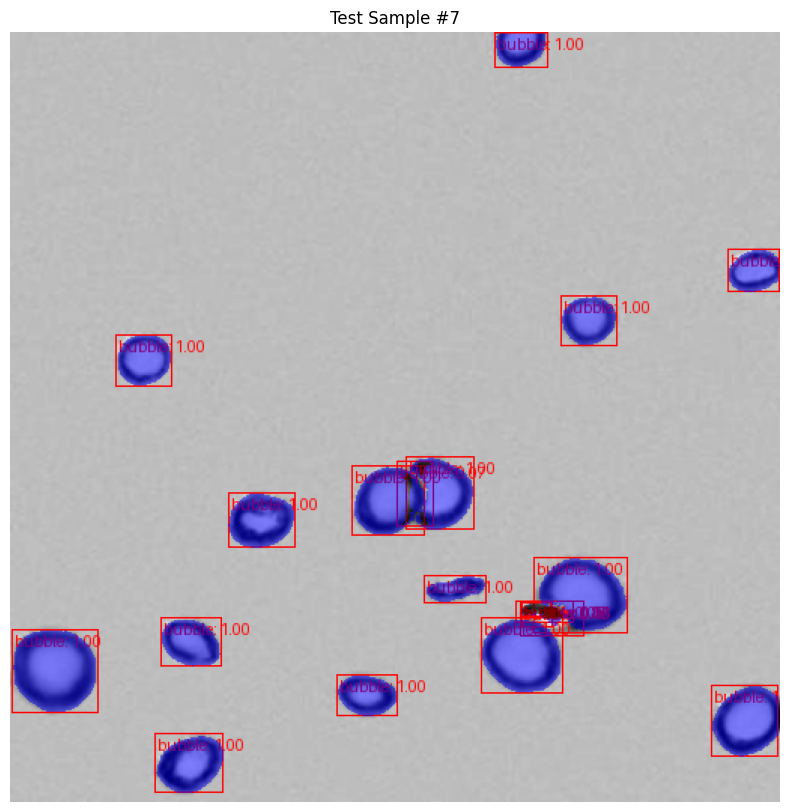

Image 8
Precision: 0.978416930822301
Recall: 0.9823551436862304
F1: 0.9803820823018357
Intersection: 20989
Union: 21829
Dice: 0.9803820822789392
Drawing predictions...


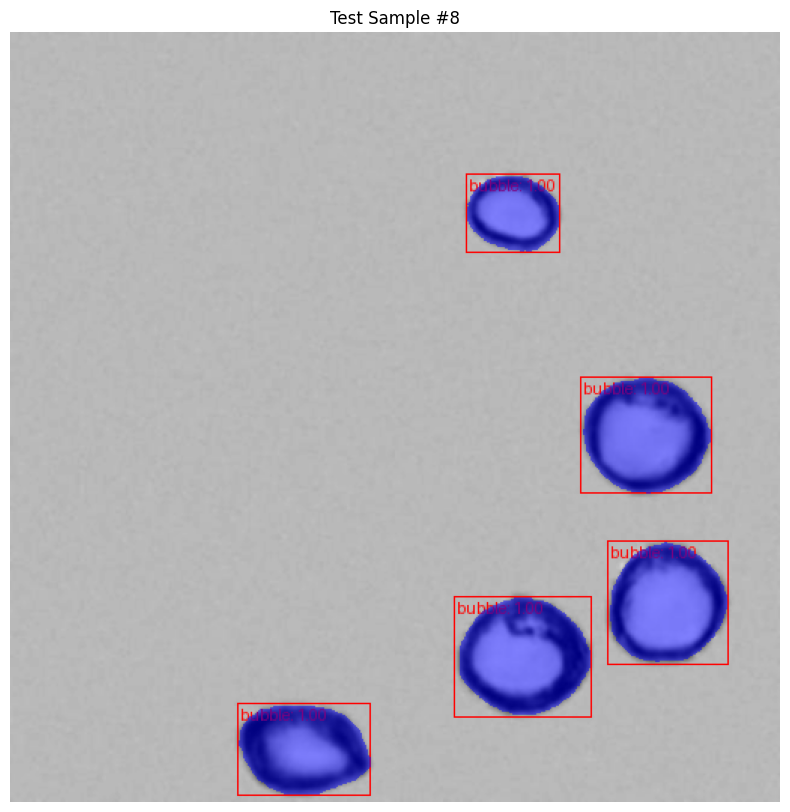

Image 9
Precision: 0.9584461667756093
Recall: 0.9747851274989315
F1: 0.9665466016903266
Intersection: 20528
Union: 21949
Dice: 0.9665466016675719
Drawing predictions...


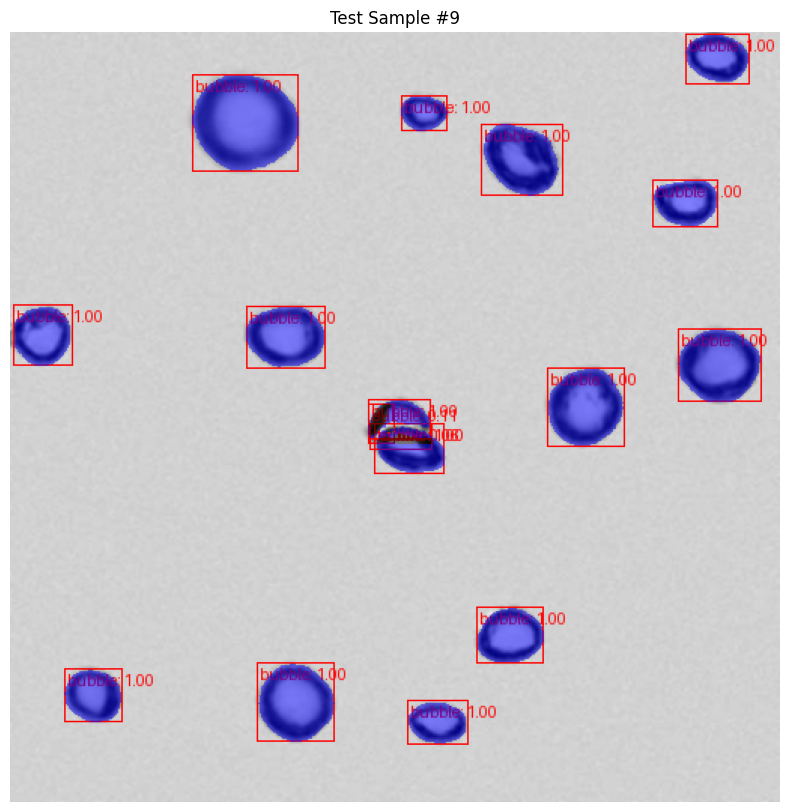

Image 10
Average Precision: 0.9776245215755509
Average Recall: 0.9506877281967533
Average F1-score: 0.9630429710310231
Average Dice Coefficient: 0.9630429710057775


In [12]:
import matplotlib.pyplot as plt
from torchvision.utils import draw_bounding_boxes, draw_segmentation_masks
import torchvision.transforms.functional as F
import torch

from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

model.eval()

# Number of test images to visualize
N = 10

with torch.no_grad():

    dice_scores = []
    precisions = []
    recalls = []
    f1_scores = []

    for idx, (image, target) in enumerate(data_loader_test):

        print(f"Image {idx}")

        if idx >= N:
            break

        x = image[0].to(device)  # batch size = 1
        x = x[:3, ...]  # Remove alpha channel if present

        pred = model([x])[0]

        pred_masks = (pred["masks"].cpu() > 0.7).squeeze(1).numpy()
        true_masks = target[0]["masks"].cpu().numpy()

        # Combine all masks into one binary mask (union of all instances)
        pred_mask = np.any(pred_masks, axis=0).astype(np.uint8)
        true_mask = np.any(true_masks, axis=0).astype(np.uint8)

        # Flatten for sklearn metrics
        pred_flat = pred_mask.flatten()
        true_flat = true_mask.flatten()

        # Skip empty ground truth
        if true_flat.sum() == 0:
            continue

        precision = precision_score(true_flat, pred_flat, zero_division=0)
        recall = recall_score(true_flat, pred_flat, zero_division=0)
        f1 = f1_score(true_flat, pred_flat, zero_division=0)
        intersection = np.logical_and(pred_mask, true_mask).sum()
        union = np.logical_or(pred_mask, true_mask).sum()
        dice = (2 * intersection) / (pred_mask.sum() + true_mask.sum() + 1e-6)

        print(f"Precision: {precision}")
        print(f"Recall: {recall}")
        print(f"F1: {f1}")
        print(f"Intersection: {intersection}")
        print(f"Union: {union}")
        print(f"Dice: {dice}")

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        dice_scores.append(dice)


        
        # Rescale image for visualization
        x_cpu = x.cpu()
        vis_img = (255.0 * (x_cpu - x_cpu.min()) / (x_cpu.max() - x_cpu.min())).to(torch.uint8)

        pred_labels = [f"bubble: {score:.2f}" for score in pred["scores"]]
        pred_boxes = pred["boxes"].cpu().long()
        masks = (pred["masks"].cpu() > 0.7).squeeze(1)

        print(f"Drawing predictions...")

        output_image = draw_bounding_boxes(vis_img, pred_boxes, pred_labels, colors="red")
        output_image = draw_segmentation_masks(output_image, masks, alpha=0.5, colors="blue")

        # Plot
        plt.figure(figsize=(10, 10))
        plt.imshow(output_image.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Test Sample #{idx}")
        plt.show()
        
        
    
    print("Average Precision:", np.mean(precisions))
    print("Average Recall:", np.mean(recalls))
    print("Average F1-score:", np.mean(f1_scores))
    print("Average Dice Coefficient:", np.mean(dice_scores))

